In [21]:
import numpy as np
import matplotlib.pyplot as plt
import json
from skimage import io
import scipy.ndimage as ndi
import re
import os
import scipy.fft as fft
import pywt
from scipy.interpolate import griddata

In [22]:
def load_image(image_path):
    """
    Loads an image from a given file path.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        numpy.ndarray: The loaded image as an array of pixels.
    """
    image = io.imread(image_path)
    return image

In [23]:
def load_json(file_path):
    """
    Loads a JSON file and returns its content.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        list/dict: The parsed JSON data.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return data

In [24]:
def get_defect_coordinates_direct(json_data):
    """
    Parses JSON data to extract defect coordinates for a single image JSON file.

    Args:
        json_data (list): The list of dictionaries loaded from the JSON file.

    Returns:
        dict: A dictionary where keys are x-coordinates (columns) and values 
              are dictionaries containing lists of 'start' and 'stop' y-coordinates.
    """
    defect_dict = {}
    
    for item in json_data:
        for x_coord in item.get('x_coord', []):
            defect_dict[x_coord] = {
                'start': item.get('y_start', []), 
                'stop': item.get('y_stop', [])
            }
    return defect_dict

In [25]:
def normalize_to_8bit(image_array):
    """
    Normalizes an image array (e.g., 16-bit) to an 8-bit range (0 to 255).

    Args:
        image_array (numpy.ndarray): The input image array.

    Returns:
        numpy.ndarray: The normalized image array with dtype uint8.
    """
    img_np = np.array(image_array, dtype=np.float32)
    
    val_min = np.min(img_np)
    val_max = np.max(img_np)
    
    if val_max == val_min:
        return np.zeros_like(img_np, dtype=np.uint8)
        
    normalized_image = ((img_np - val_min) / (val_max - val_min)) * 255
    
    return normalized_image.astype(np.uint8)

In [26]:
def create_defect_mask_2d(shape, defect_dict):
    """
    Creates a 2D boolean mask pinpointing the exact locations of the defects 
    based on the provided defect dictionary coordinates.

    Args:
        shape (tuple): The (nrow, ncol) shape of the target image matrix.
        defect_dict (dict): A dictionary where keys are x-coordinates (columns) and values 
                            are dictionaries containing lists of 'start' and 'stop' y-coordinates.
            
    Returns:
        ndarray: A 2D boolean array where True indicates a defective pixel.
    """
    nrow, ncol = shape
    mask_2d = np.zeros(shape, dtype=bool)
    
    if not defect_dict:
        return mask_2d

    for col, intervals in defect_dict.items():
        if not (0 <= col < ncol):
            continue
        
        starts = intervals.get('start', [])
        stops = intervals.get('stop', [])
        
        # Run through each pair of Y intervals for this X column
        for y_start, y_stop in zip(starts, stops):
            y_start_clamped = max(0, int(y_start))
            y_stop_clamped = min(nrow, int(y_stop))
            
            mask_2d[y_start_clamped:y_stop_clamped, col] = True
            
    return mask_2d

In [27]:
def correct_stripes_with_wavelet_fourier(original_image, defect_dict, wavelet='db5', level=3, sigma=2.0):
    """
    Filters and corrects stripe defects using the classic Wavelet-Fourier (Münch/Algotom) 
    de-striping algorithm combined with local 2D masking.
    
    This method decomposes the image via Discrete Wavelet Transform (DWT), applies a 
    Fourier-domain Gaussian filter to the vertical coefficients to eliminate stripe noise, 
    reconstructs the image, and blends it locally onto the defective regions.

    Args:
        original_image : array_like 
            2D image array.
        defect_dict : dict
            A dictionary where keys are x-coordinates (columns) and values 
            are dictionaries containing lists of 'start' and 'stop' y-coordinates.
        wavelet : str
            Mother wavelet type (e.g., 'db5', 'sym16', 'haar').
        level : int
            Decomposition level for DWT.
        sigma : float
            Damping factor (Gaussian width) for the Fourier filter. Larger values filter more.
            
    Returns:
        array_like: The corrected 16-bit unsigned integer image matrix.
    """
    final_output = np.copy(original_image)
    
    # Generate exact 2D mask using the separated utility function
    exact_mask_2d = create_defect_mask_2d(final_output.shape, defect_dict)
                    
    if not np.any(exact_mask_2d):
        return original_image.astype(np.uint16)

    mat_float = original_image.astype(np.float32)
    nrow, ncol = mat_float.shape

    # Layer 1: Wavelet Decomposition (DWT)
    # Decompose the image into approximation (cA) and detail coefficients (cH, cV, cD)
    coeffs = pywt.wavedec2(mat_float, wavelet=wavelet, level=level)
    coeffs_list = list(coeffs)

    # Layer 2: Fourier Filtering on Vertical Coefficients (cV) at each level
    for i in range(1, len(coeffs_list)):
        # coeffs_list[i] is a tuple: (cH, cV, cD)
        cH, cV, cD = coeffs_list[i]
        
        # Perform 1D FFT along the vertical columns of the vertical detail coefficients
        # Stripes manifest as high-energy components around the central horizontal line in FFT space
        v_fft = fft.fft(cV, axis=0)
        v_fft_shift = fft.fftshift(v_fft, axes=0)
        
        # Create a 1D Gaussian damping filter to suppress stripe frequencies
        v_nrow, v_ncol = v_fft_shift.shape
        center = v_nrow // 2
        
        # Generate coordinates relative to the center
        y_indices = np.arange(v_nrow) - center
        
        # 1D Gaussian notch-like filter profile
        if sigma > 0:
            # Avoid division by zero and construct the damping factor
            filter_1d = 1.0 - np.exp(-(y_indices**2) / (2 * (sigma**2)))
            # Reshape for broadcasting across columns
            filter_2d = filter_1d[:, np.newaxis]
            
            # Apply filter to damp the components causing vertical stripes
            v_fft_shift *= filter_2d
            
        # Inverse FFT back to Wavelet space
        v_fft_back = fft.ifftshift(v_fft_shift, axes=0)
        cV_filtered = np.real(fft.ifft(v_fft_back, axis=0))
        
        # Update the coefficients list with the filtered vertical components
        coeffs_list[i] = (cH, cV_filtered, cD)

    # Layer 3: Wavelet Reconstruction (IDWT)
    mat_wavelet_corrected = pywt.waverec2(coeffs_list, wavelet=wavelet)
    
    # Handle minor size mismatches that can occur during IDWT due to rounding/padding
    mat_wavelet_corrected = mat_wavelet_corrected[:nrow, :ncol]

    # Layer 4: Fusion and Final Masked Compositing
    # Clip and cast to preserve 16-bit dynamic range
    mat_corrected_16bit = np.clip(np.round(mat_wavelet_corrected), 0, 65535).astype(np.uint16)
    
    # Replace only the defective regions; clean areas remain completely untouched
    final_output[exact_mask_2d] = mat_corrected_16bit[exact_mask_2d]
    
    return final_output.astype(np.uint16)

In [28]:
def display_comparison(image_path, original_image, processed_image):
    """
    Finds the ground truth image, normalizes all 3 16-bit matrices to 8-bit, and plots
    3 images side-by-side comparison.

    Args:
        image_path (str): Complete path to the current input image.
        original_image (numpy.ndarray): The raw original 16-bit image array.
        processed_image (numpy.ndarray): The destriped 16-bit image array.
    """
    
    gt_path = re.sub(r"low dyn with columns \d+", "low dyn", image_path)
    ground_truth_image = load_image(gt_path)

    # Scale images to 8-bit strictly for display rendering pipeline
    original_image_8bits = normalize_to_8bit(original_image)
    processed_image_8bits = normalize_to_8bit(processed_image)
    gt_image_8bits = normalize_to_8bit(ground_truth_image)

    # Create the dynamic plot grid configuration
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))

    # Plot 1: The original corrupted image
    axes[0].imshow(original_image_8bits, cmap='gray')
    axes[0].set_title("Image WITH Defects", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Plot 2: The destriped image processed by your pipeline
    axes[1].imshow(processed_image_8bits, cmap='gray')
    axes[1].set_title("Corrected Image", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Plot 3: The Ground Truth clean image (matches input resolution automatically)
    axes[2].imshow(gt_image_8bits, cmap='gray')
    axes[2].set_title("Ground Truth Image", fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    plt.close(fig)

In [29]:
def pipeline_process_image_pure(image_path, json_path, show_result=True):
    """
    Processes an image using frequency separated interpolation algorithm
    Directly maps defect locations from a JSON configuration.

    Args:
        image_path (str): Path to read the target input image.
        json_path (str): Path to read the single image configuration JSON file.
        show_result (bool): If True, plots the side-by-side comparison on screen.

    Returns:
        corrected_image_16bit (numpy.ndarray): The resulting destriped 16-bit image array matrix.
    """
    # Load the original image 
    original_image = load_image(image_path)
    
    # Load the JSON data
    json_data = load_json(json_path)
        
    # Extract defect coordinates 
    defect_coords = get_defect_coordinates_direct(json_data)
    
    # Compute the correction matrix using the advanced Hybrid Frequency Split method
    corrected_image_16bit = correct_stripes_with_wavelet_fourier(original_image, defect_coords)
    
    # Display
    if show_result:
        display_comparison(image_path, original_image, corrected_image_16bit)
        
    return corrected_image_16bit

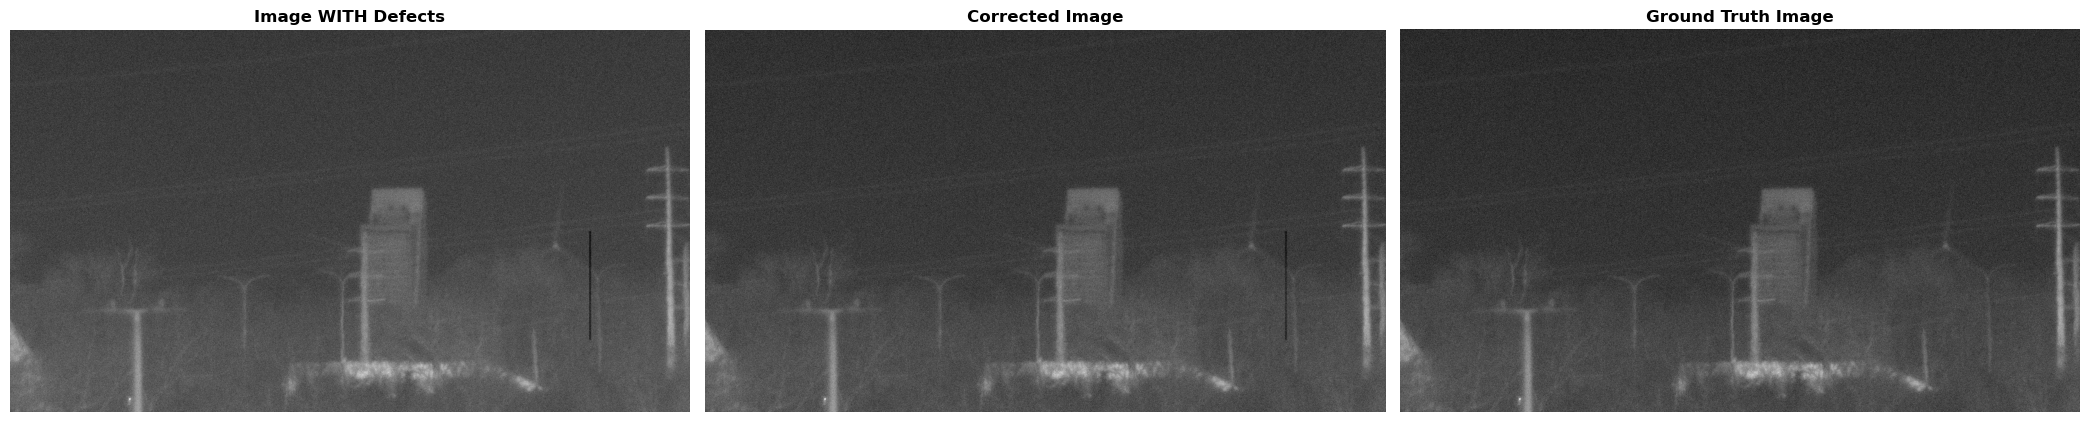

In [30]:
image_path = "/Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/HD/sequence_1/low dyn with columns 2/frame_0043.png"
json_path  = "/Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/HD/sequence_1/low dyn with columns 2/HD_sequence_1_config_2.json"

img_clean_16bit = pipeline_process_image_pure(image_path, json_path, show_result=True)